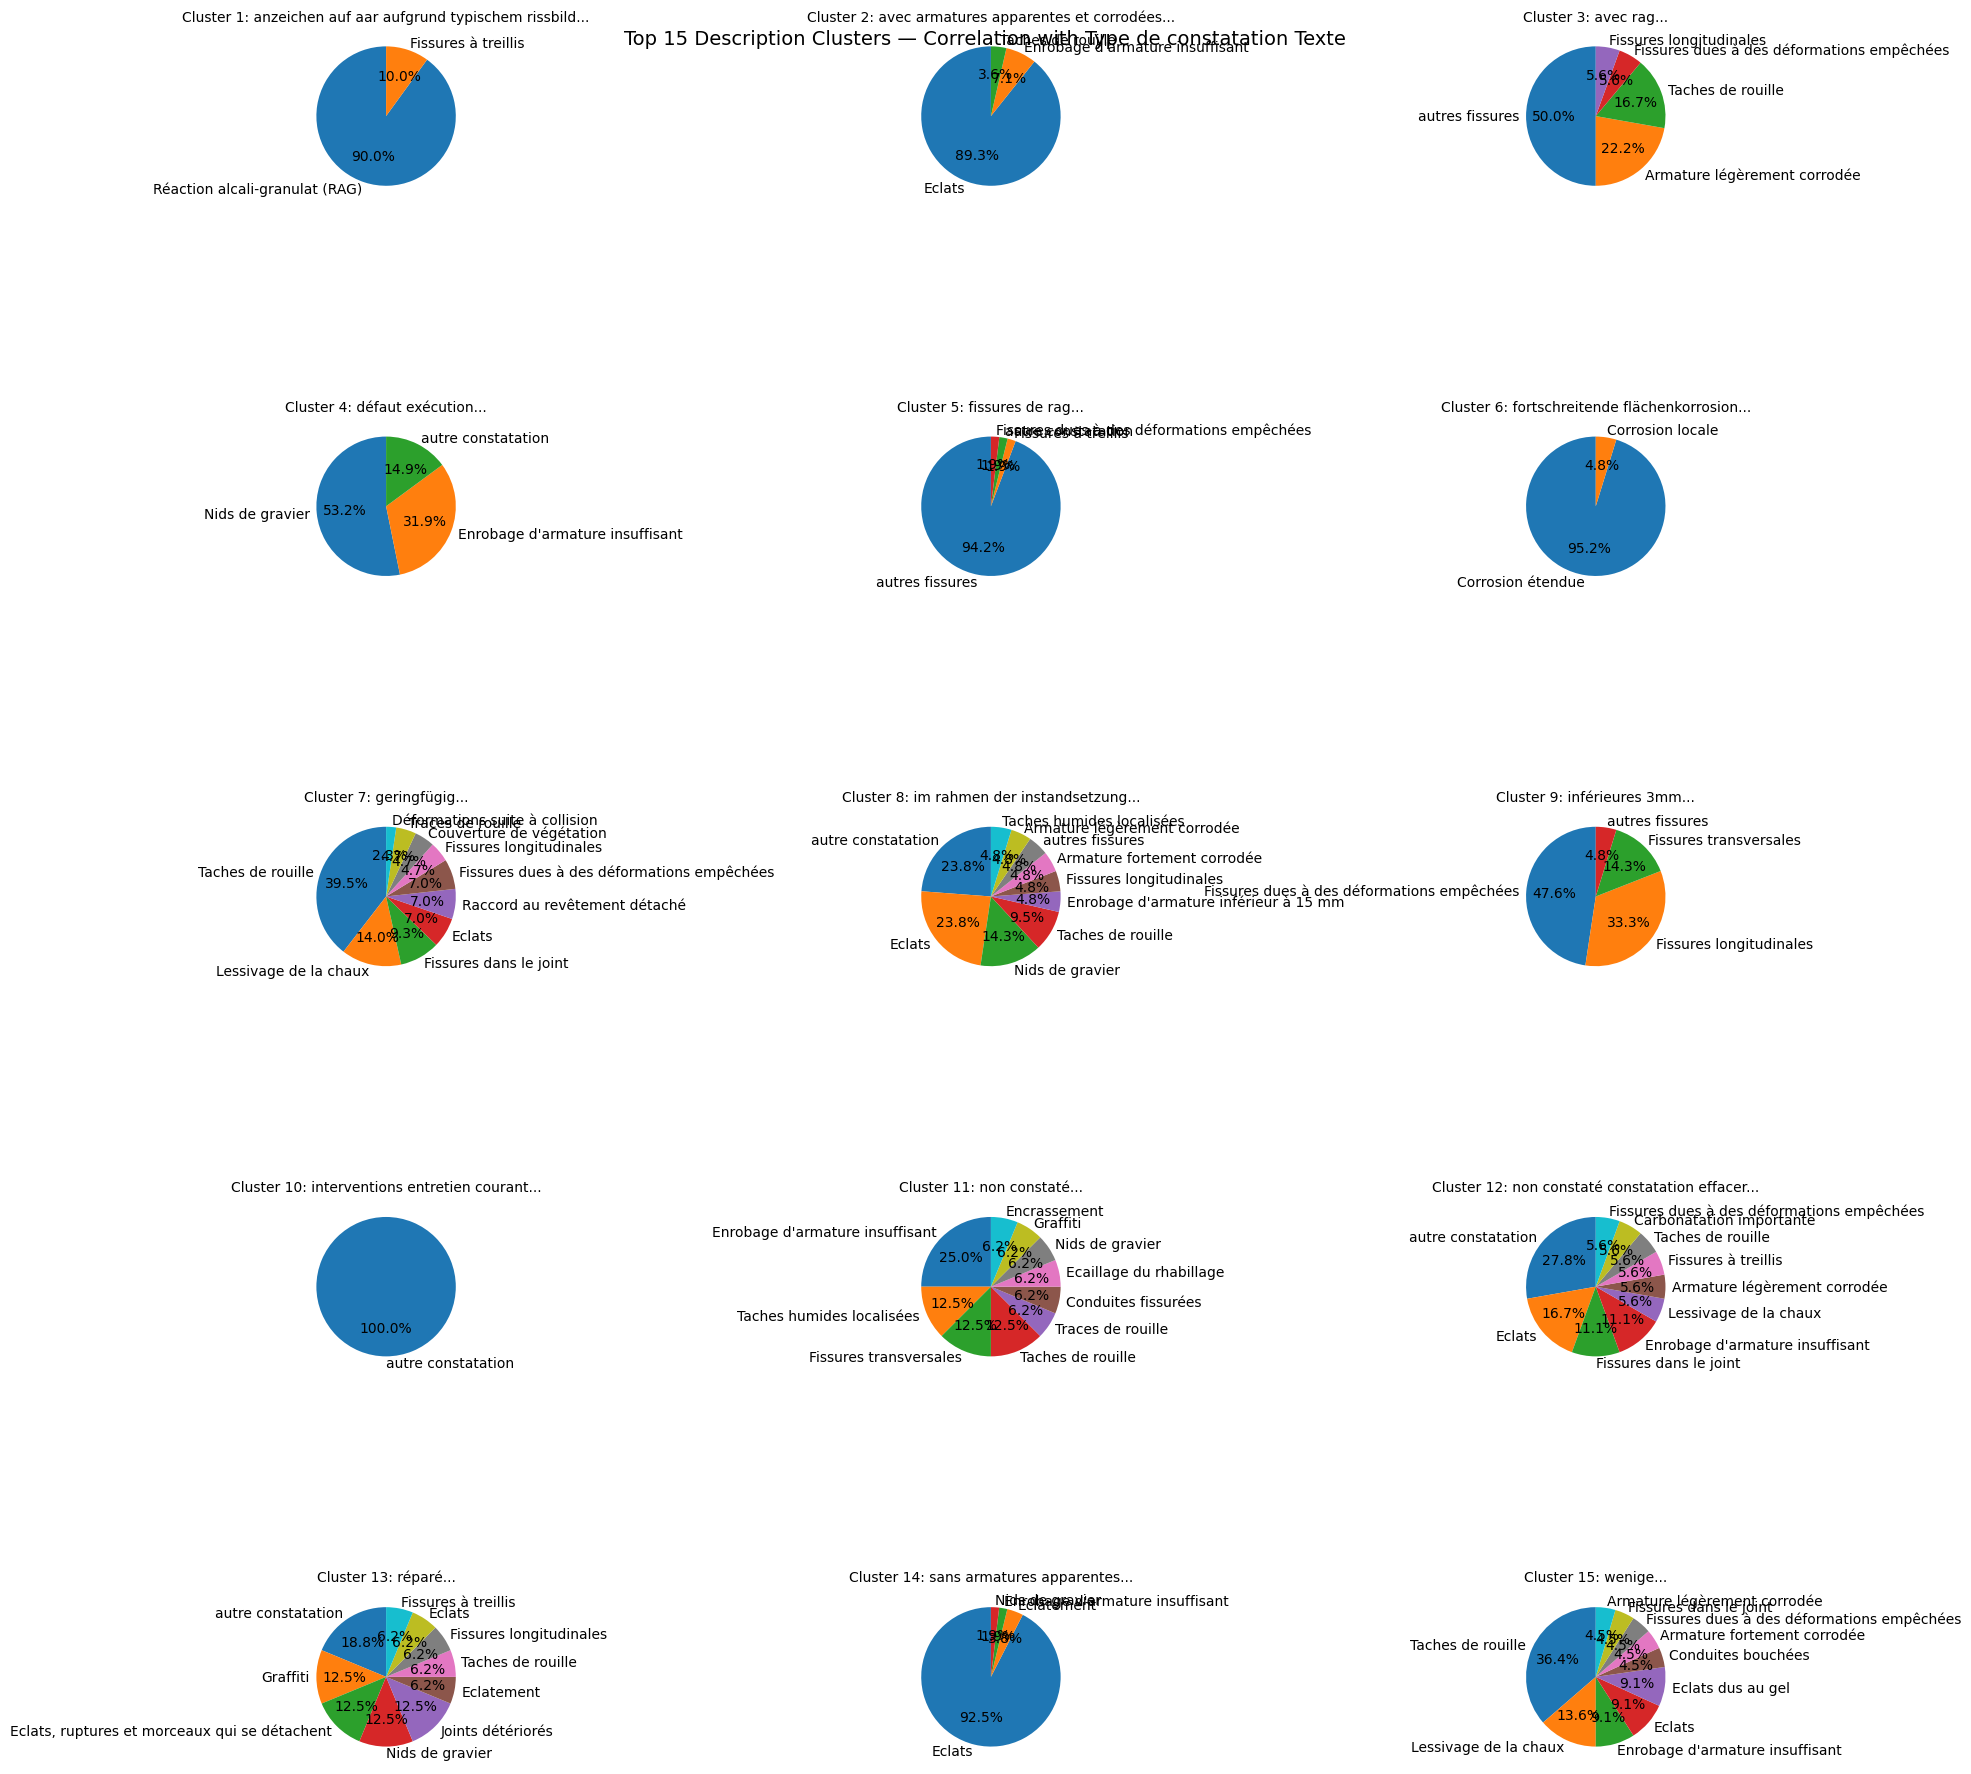

✅ Saved figure: description_type_pies.png


In [1]:
# ==============================
# PART 2 — PLOTTING
# Plot 5x3 pies for the 15 most relevant clusters
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# CONFIG
# ------------------------------
sep = ";"
corr_file = "description_type_correlations.csv"
max_clusters = 15
max_types_per_cluster = 10

# ------------------------------
# LOAD DATA
# ------------------------------
corr_df = pd.read_csv(corr_file, sep=sep)
if corr_df.empty:
    raise ValueError("Correlation file is empty — run Part 1 first.")

# Get top N clusters by Description_Count
top_clusters = corr_df.groupby("Description_Cluster")["Description_Count"].max().nlargest(max_clusters).index
plot_df = corr_df[corr_df["Description_Cluster"].isin(top_clusters)]

# ------------------------------
# CREATE PIE PLOTS
# ------------------------------
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (cluster, subdf) in enumerate(plot_df.groupby("Description_Cluster")):
    if i >= len(axes): break
    subdf_sorted = subdf.sort_values("Type_Count", ascending=False).head(max_types_per_cluster)
    axes[i].pie(subdf_sorted["Type_Count"], labels=subdf_sorted["Type_de_constatation"], autopct="%1.1f%%", startangle=90)
    axes[i].set_title(f"Cluster {i+1}: {cluster[:60]}...", fontsize=10)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Top 15 Description Clusters — Correlation with Type de constatation Texte", fontsize=14, y=0.92)
plt.tight_layout()
plt.savefig("description_type_pies.png", dpi=300)
plt.show()
print("✅ Saved figure: description_type_pies.png")
